In [160]:
import pandas as pd # to load and manipulate data and for One-Hot Encoding
import numpy as np # to calculate the argmax for 5 fold cv
import matplotlib.pyplot as plt # to draw graphs
import seaborn as sns # to beautify my graphs
from sklearn.tree import DecisionTreeClassifier # to build a classification tree
from sklearn.tree import plot_tree # to draw a classification tree
from sklearn.model_selection import train_test_split # to split data into training and testing sets
from sklearn.model_selection import cross_val_score # for cross validation
from sklearn.metrics import ConfusionMatrixDisplay # creates and draws a confusion matrix
from sklearn.metrics import classification_report, roc_auc_score #for respective reports

In [161]:
# Removing warnings because who wants to see them
import warnings
warnings.filterwarnings("ignore")

# Display settings for easier DataFrame viewing
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# 1. Data Preprocessing and Cleaning
*In this section, I handle missing values using median imputation (justified by boxplot outlier analysis), remove illogical outliers (age/employment > 100), and encode categorical variables using both ordinal and one-hot encoding to prepare the data for modeling.*

In [162]:
df = pd.read_csv('credit_risk_dataset.csv')

In [163]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.00,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.00,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.00,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.00,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.00,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [164]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (32581, 12)

Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Data types:
 person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object


In [165]:
print(" Null counts ")
print(df.isnull().sum()) # no nulls were found, great

 Null counts 
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [166]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

print("Columns after cleaning:", df.columns.tolist())

Columns after cleaning: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [167]:
df[~(df['loan_int_rate'].isnull() | df['person_emp_length'].isnull())]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.00,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.00,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.00,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.00,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.00,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.00,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.00,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.00,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.00,PERSONAL,B,15000,11.48,0,0.10,N,26


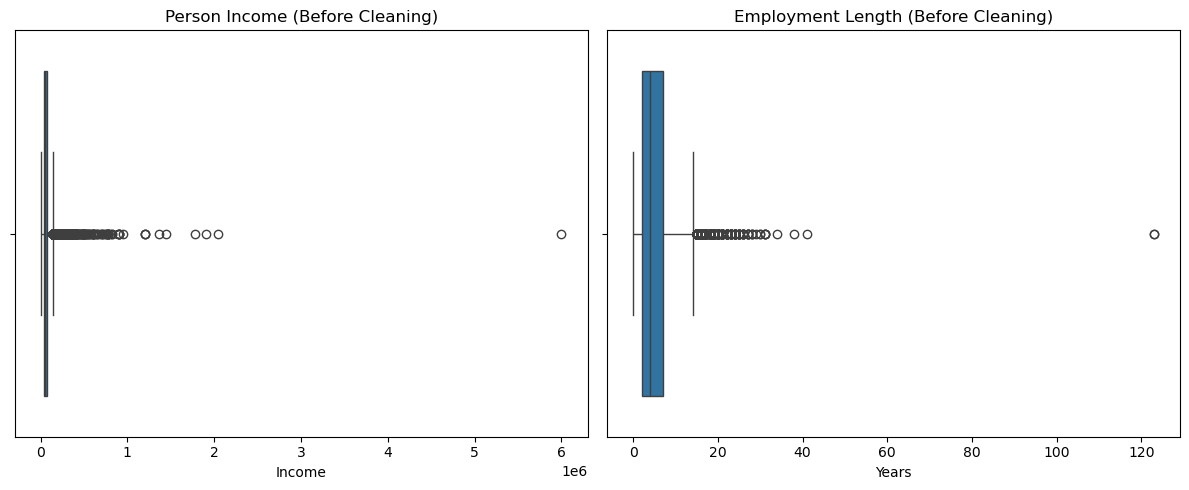

In [168]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['person_income'])
plt.title('Person Income (Before Cleaning)')
plt.xlabel('Income')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['person_emp_length'])
plt.title('Employment Length (Before Cleaning)')
plt.xlabel('Years')

plt.tight_layout()
plt.show()

## Data Distribution Analysis (Before Cleaning)

### Key Observations from Boxplots:

**1. Person Income Distribution:**
- Income is highly right-skewed
- There are some extreme outliers, with a few values going above $6M
- Most data concentrated at lower income levels
- Because of these extreme values, the mean income can be much higher

**2. Employment Length Distribution:**
- Employment length is also highly right-skewed
- There is one extreme value of around 123 years, which is not realistic
- Most values are between 0–5 years
- There are also some values above 40 years, which look unusual and can affect calculations

### Why Median Imputation:

- Median less affected by extreme outliers than mean
- Extreme values like $6M income or 123 years of employment can pull the mean up
- Median gives a value closer to what is flowing in the data
- So, for missing values, median should give more reasonable values than mean




In [169]:
# Checking current state
print(" BEFORE CLEANING ")
print(f"Shape: {df.shape}")
print(f"\nNull values:\n{df.isnull().sum()}")

 BEFORE CLEANING 
Shape: (32581, 12)

Null values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [170]:
# Removing illogical outliers
print(" REMOVING ILLOGICAL OUTLIERS ")
print(f"Rows with person_age > 100: {(df['person_age'] > 100).sum()}")
print(f"Rows with person_emp_length > 100: {(df['person_emp_length'] > 100).sum()}")

# Drop rows with impossible values
df = df[(df['person_age'] <= 100) & (df['person_emp_length'] <= 100)]

print(f"\nShape after removing outliers: {df.shape}")

 REMOVING ILLOGICAL OUTLIERS 
Rows with person_age > 100: 5
Rows with person_emp_length > 100: 2

Shape after removing outliers: (31679, 12)


In [171]:
# STEP 3: NOW calculate median on CLEAN data
print(" CALCULATING MEDIANS ")
median_emp_length = df['person_emp_length'].median()
median_loan_int_rate = df['loan_int_rate'].median()

print(f"Median Employment Length: {median_emp_length:.2f} years")
print(f"Median Loan Interest Rate: {median_loan_int_rate:.2f}%")

 CALCULATING MEDIANS 
Median Employment Length: 4.00 years
Median Loan Interest Rate: 10.99%


In [172]:
# STEP 4: Impute missing values
print(" IMPUTING MISSING VALUES ")
df['person_emp_length'] = df['person_emp_length'].fillna(median_emp_length)
df['loan_int_rate'] = df['loan_int_rate'].fillna(median_loan_int_rate)

# Verify
print("\n AFTER IMPUTATION ")
print(f"Remaining nulls:\n{df.isnull().sum()}")

 IMPUTING MISSING VALUES 

 AFTER IMPUTATION 
Remaining nulls:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [173]:
print(" ENCODING CATEGORICAL VARIABLES ")
print(f"Shape before encoding: {df.shape}")

# 1. Ordinal Encoding for loan_grade (preserves order: A=0, B=1, C=2, etc.)
grade_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}
df['loan_grade'] = df['loan_grade'].map(grade_mapping)

# 2. Binary encoding for cb_person_default_on_file (Y=1, N=0)
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

# 3. One-Hot Encoding for nominal variables (no order)
df_encoded = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent']) 

 ENCODING CATEGORICAL VARIABLES 
Shape before encoding: (31679, 12)


In [174]:
print(f"Shape after encoding: {df_encoded.shape}")
print(f"Columns added: {df_encoded.shape[1] - df.shape[1]}")


Shape after encoding: (31679, 20)
Columns added: 8


In [175]:
print(df_encoded.head())

   person_age  person_income  person_emp_length  loan_grade  loan_amnt  \
1          21           9600               5.00        1.00       1000   
2          25           9600               1.00        2.00       5500   
3          23          65500               4.00        2.00      35000   
4          24          54400               8.00        2.00      35000   
5          21           9900               2.00        0.00       2500   

   loan_int_rate  loan_status  loan_percent_income  cb_person_default_on_file  \
1          11.14            0                 0.10                          0   
2          12.87            1                 0.57                          0   
3          15.23            1                 0.53                          0   
4          14.27            1                 0.55                          1   
5           7.14            1                 0.25                          0   

   cb_person_cred_hist_length  person_home_ownership_MORTGAGE  \
1  

In [176]:
# renaming some columns because the dont look good
df_encoded = df_encoded.rename(columns={
    'loan_intent_DEBTCONSOLIDATION': 'intent_debt',
    'loan_intent_HOMEIMPROVEMENT': 'intent_home',
    'loan_intent_EDUCATION': 'intent_edu',
    'loan_intent_MEDICAL': 'intent_med',
    'loan_intent_PERSONAL': 'intent_personal',
    'loan_intent_VENTURE': 'intent_venture'
})

# Check the result
print(df_encoded[['intent_debt', 'intent_home']].head())

   intent_debt  intent_home
1        False        False
2        False        False
3        False        False
4        False        False
5        False        False


In [177]:
df_encoded.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,intent_debt,intent_edu,intent_home,intent_med,intent_personal,intent_venture
1,21,9600,5.00,1.00,1000,11.14,0,0.10,0,2,False,False,True,False,False,True,False,False,False,False
2,25,9600,1.00,2.00,5500,12.87,1,0.57,0,3,True,False,False,False,False,False,False,True,False,False
3,23,65500,4.00,2.00,35000,15.23,1,0.53,0,2,False,False,False,True,False,False,False,True,False,False
4,24,54400,8.00,2.00,35000,14.27,1,0.55,1,4,False,False,False,True,False,False,False,True,False,False
5,21,9900,2.00,0.00,2500,7.14,1,0.25,0,2,False,False,True,False,False,False,False,False,False,True


# FEATURE ENGINEERING
*The original columns are useful, but some useful signals come from combining them*
*Here we create 4 new features to capture things like employment stability, credit history, interest cost and loan risk*

In [178]:
# Running these for feature engineering, to check for denominator
print(f' Minimum credit history length :- {df_encoded['cb_person_cred_hist_length'].min()}')
print(f' Minimum age of person in df :- {df_encoded['person_age'].min()}')

 Minimum credit history length :- 2
 Minimum age of person in df :- 20


In [179]:
# STEP 6: FEATURE ENGINEERING
print(" FEATURE ENGINEERING ")

 FEATURE ENGINEERING 


In [180]:
# 1. Employment to Age Ratio
# How much of their age they have been employed
# Minimum age is 20, so no division by zero issue
df_encoded['employment_to_age_ratio'] = df_encoded['person_emp_length'] / df_encoded['person_age']

In [181]:
# 2. Credit History Ratio
# How early they started building credit
df_encoded['credit_history_ratio'] = df_encoded['cb_person_cred_hist_length'] / df_encoded['person_age']

# 3. Interest Burden
# Approx interest amount on top of the loan amount
# Gives an idea of the actual interest cost
df_encoded['interest_burden'] = (df_encoded['loan_int_rate'] / 100) * df_encoded['loan_amnt']

# 4. Loan to Credit History Ratio
# Large loan with less credit history can mean higher risk
# SINCE MINIMUM IS 2, NO ADJUSTMENT REQUIRED
df_encoded['loan_to_cred_hist_ratio'] = df_encoded['loan_amnt'] / (df_encoded['cb_person_cred_hist_length'])

In [182]:
# Check if any new nulls were created
print(f"New shape: {df_encoded.shape}")
print("New features created: 'employment_to_age_ratio', 'credit_history_ratio', 'interest_burden', 'loan_to_cred_hist_ratio'")
print(f"\nAny new nulls? \n{df_encoded[['employment_to_age_ratio', 'credit_history_ratio', 'interest_burden', 'loan_to_cred_hist_ratio']].isnull().sum()}")

New shape: (31679, 24)
New features created: 'employment_to_age_ratio', 'credit_history_ratio', 'interest_burden', 'loan_to_cred_hist_ratio'

Any new nulls? 
employment_to_age_ratio    0
credit_history_ratio       0
interest_burden            0
loan_to_cred_hist_ratio    0
dtype: int64


In [183]:
df = df_encoded.copy() #i cant write df_encoded everytime, df is better

# TRAINING AND INTERPRETING A DECISION TREE

In [184]:
# SEPARATING FEATURES
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [185]:
# SPLITTING THE DATASET
# stratify=y ensures the ratio of 1s to 0s is the same in both sets.
# This is crucial because defaults are the minority class.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [186]:
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (25343, 23)
Testing set shape: (6336, 23)


In [187]:
# Initialize the Decision Tree
model = DecisionTreeClassifier(
    criterion='gini',             # Gini used for binary classification, ALSO FASTER
    max_depth=5,                  # Limit tree depth to reduce overfitting
    min_samples_split=20,         # At least 20 samples needed to split
    min_samples_leaf=10,          # At least 10 samples needed in each leaf
    max_features=None,            # Use all features for finding the best split
    class_weight='balanced',      # Gives more weight to the minority class
    random_state=42               # Keeps the result same each time
)

In [188]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [189]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [190]:
# Evaluation
print("\n MODEL EVALUATION ")
print(classification_report(y_test, y_pred, target_names=['Repaid (0)', 'Defaulted (1)']))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")


 MODEL EVALUATION 
               precision    recall  f1-score   support

   Repaid (0)       0.93      0.97      0.95      4971
Defaulted (1)       0.89      0.72      0.80      1365

     accuracy                           0.92      6336
    macro avg       0.91      0.85      0.87      6336
 weighted avg       0.92      0.92      0.92      6336

ROC-AUC Score: 0.9006


## Model Evaluation & Business Interpretation

### 1. ROC-AUC Score: 0.9006

- ROC-AUC is 0.9006
- Around 0.90 means the model is able to separate defaulters and repayers quite well
- For a single Decision Tree, this is a good baseline

### 2. Precision vs Recall for Defaulters

In credit risk, missing an actual defaulter can be more costly than wrongly flagging a repayer

- **Recall: 0.72 / 72%**
  - Out of all actual defaulters, the model catches around 72%
  - So around 3 out of 4 defaulters are being identified

- **Precision: 0.89 / 89%**
  - When the model marks someone as high risk, it is correct around 89% of the time
  - So most of the people being flagged are actually defaulters

### 3. Why Accuracy is not enough

- Accuracy is 92%
- But the dataset is imbalanced, with more repayers than defaulters
- A model can get high accuracy just by predicting most people as repayers
- So accuracy alone does not tell us how well the model is finding defaulters
- ROC-AUC and recall give a better idea of how well the model is identifying risky borrowers

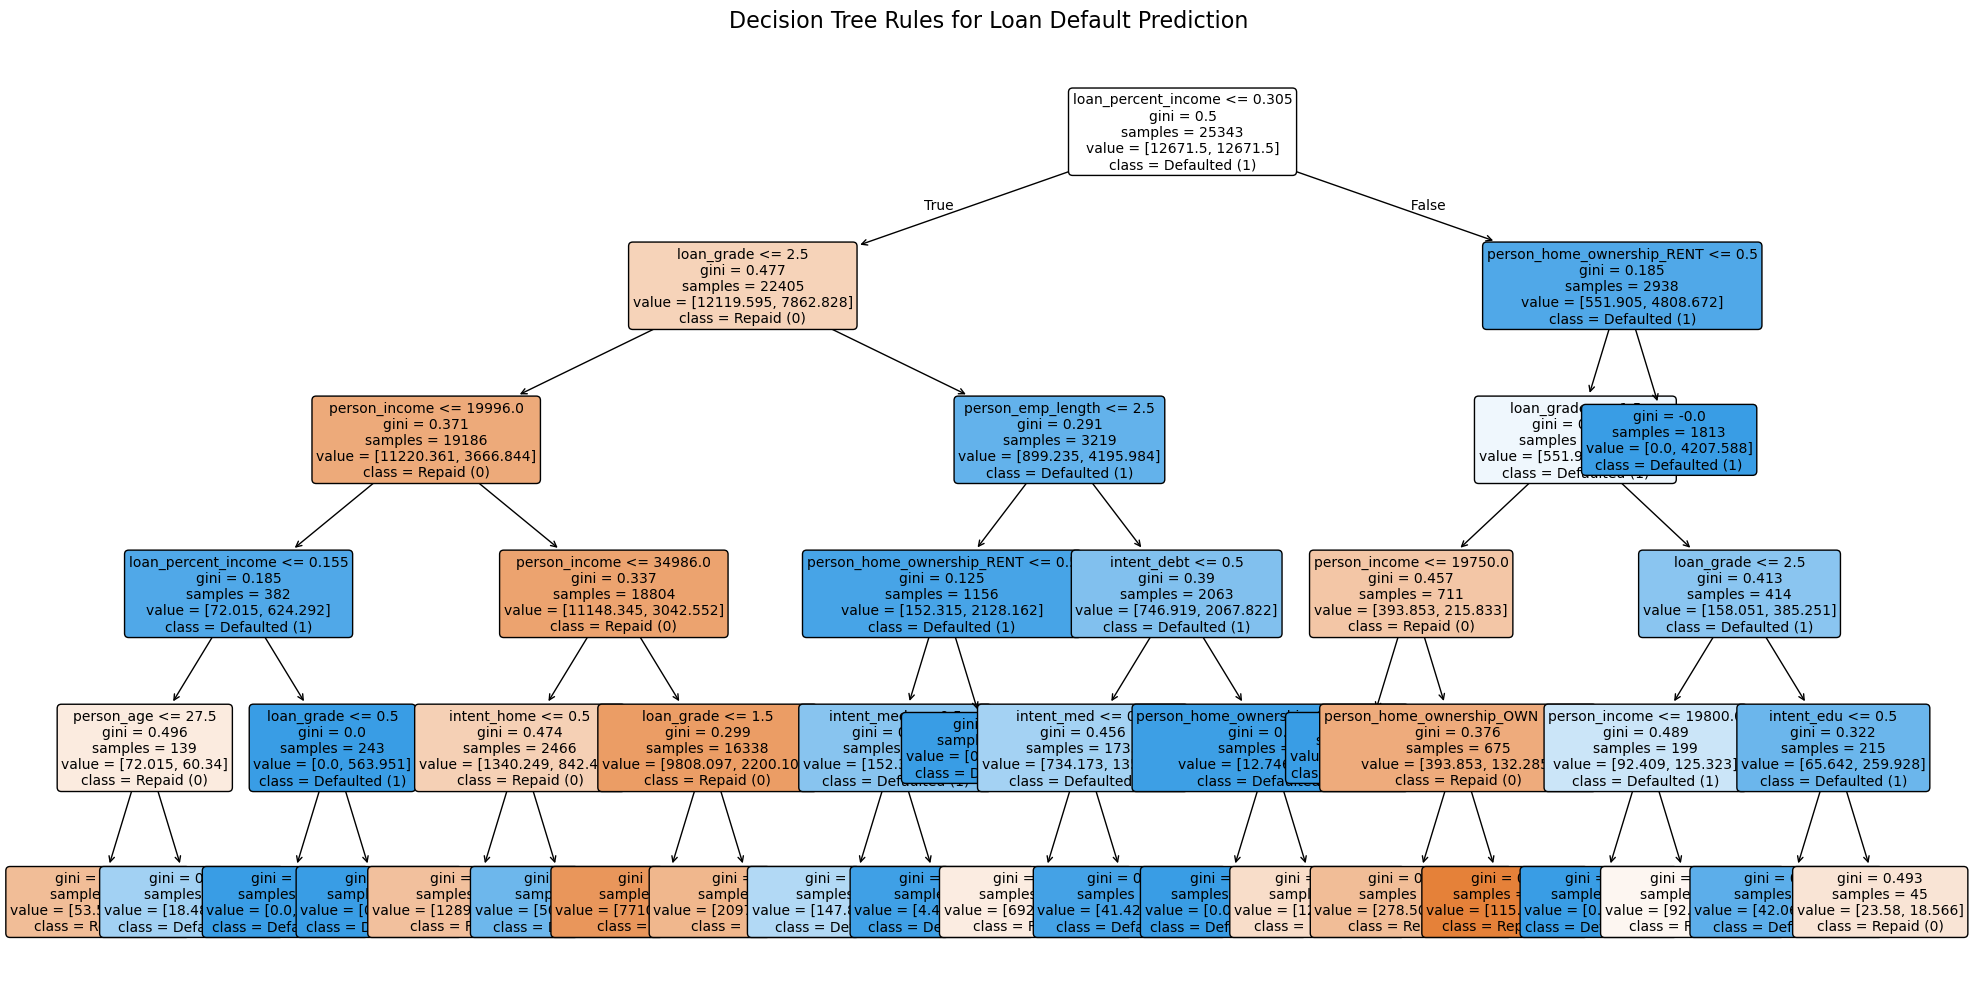

In [191]:
# Plot the Decision Tree
plt.figure(figsize=(20, 10)) # Made it wider to fit the branches cleanly

plot_tree(
    model,
    filled=True,          # Colors nodes based on majority class (Orange=Default, Blue=Repaid)
    rounded=True,         # Makes it look polished
    class_names=['Repaid (0)', 'Defaulted (1)'], # Clear labels
    feature_names=X.columns,
    fontsize=10,          # Keeps text readable
    max_depth=5           # Ensures it only plots up to the depth we set
)

plt.title('Decision Tree Rules for Loan Default Prediction', fontsize=16, pad=20)
plt.tight_layout()

# Save the high-quality image for your GitHub README or interview presentation
plt.savefig('decision_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# looks like too many nodes, will require pruning

In [192]:
# Feature Importance (The "Explainability" Factor)
importances = model.feature_importances_
feature_names = X.columns

# Create a dataframe to sort and view the top drivers of default
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)


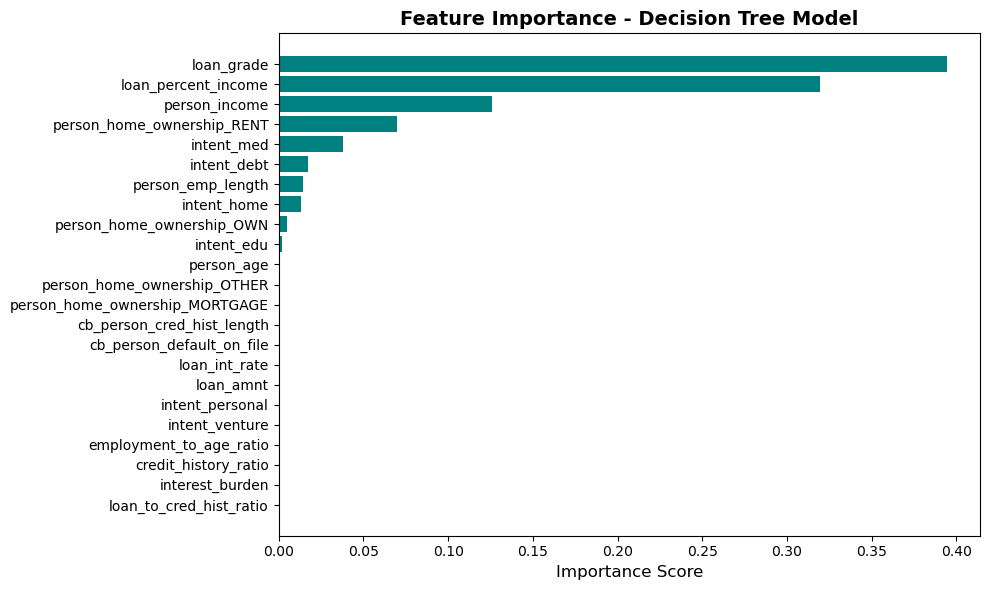

In [193]:
# 3. Plot the Feature Importance
plt.figure(figsize=(10, 6))

# Horizontal bar chart
plt.barh(importance_df['feature'], importance_df['importance'], color='teal')

# Formatting
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance - Decision Tree Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Puts the highest importance feature at the very top
plt.tight_layout()        # Prevents labels from being cut off

# Save the image for your GitHub/Portfolio
plt.savefig('feature_importance_dt.png', dpi=300, bbox_inches='tight')

plt.show()

## Feature Importance Analysis & Business Interpretation

The chart shows which features the Decision Tree used more while predicting loan defaults

### 1. Main Features

The top 3 features make up around 82% of the total importance

- **`loan_grade` (~39%)**
  - Most important feature in the model
  - Lower loan grades like D, E and F are linked with higher default risk
  - Makes sense since loan grade already reflects the borrower's credit risk

- **`loan_percent_income` (~31%)**
  - Shows how much of the person's income goes towards the loan
  - Higher percentage means more pressure on income
  - So higher values can mean higher default risk

- **`person_income` (~12%)**
  - Gives an idea about repayment capacity
  - Higher income generally means more room to handle the loan

### 2. Other Important Features

- **`person_home_ownership_RENT` (~7%)**
  - Renters have somewhat higher default risk in this dataset compared to other ownership groups

- **`intent_med` and `intent_debt`**
  - Medical and debt consolidation loans also show some importance
  - These may be linked with existing financial pressure


<Figure size 800x600 with 0 Axes>

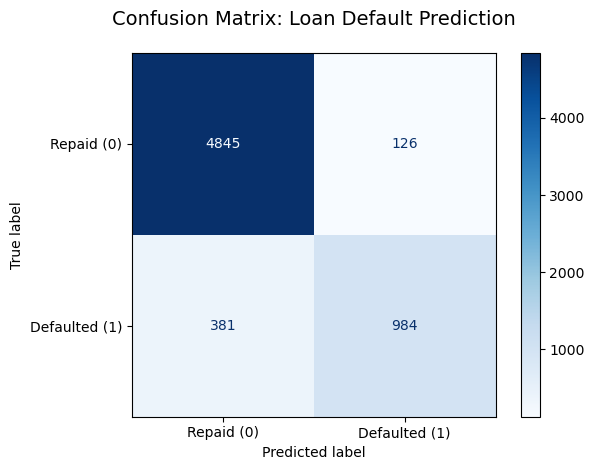

In [194]:
plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_estimator(
    model,                # Your trained Decision Tree
    X_test, 
    y_test,
    display_labels=["Repaid (0)", "Defaulted (1)"],
    cmap="Blues",         
    values_format="d"     # Display whole numbers instead of decimals
)

plt.title("Confusion Matrix: Loan Default Prediction", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Evaluating the Classification Tree

In the confusion matrix, we can see that:

* Out of **4971 people who repaid the loan** (4845 + 126), **4845 (97%)** were correctly classified
* Out of **1365 people who defaulted** (381 + 984), **984 (72%)** were correctly classified
* The model missed **381 defaulters**, which is something to keep in mind for a credit risk model
* When the model predicts someone as a defaulter, it is correct about **89%** of the time (984 / 1110)

### Can we do better?

The model is doing quite well for identifying repayers, but it is missing some defaulters

One possible way to improve this is to adjust the tree parameters or try other models

For now, this gives us a good baseline for the classification task

# PRUNING THE TREE

In [195]:

path = model.cost_complexity_pruning_path(X_train, y_train)# Determine the values for alpha
ccp_alphas = path.ccp_alphas # Extract the different values for alpha
ccp_alphas = ccp_alphas[:-1] # Exclude the maximum value for alpha, since we dont want that aggressive of a pruning
models = [] # Create an empty list to store the Decision Trees

print(f"Number of alpha values to test: {len(ccp_alphas)}")
print(f"Alpha range: {ccp_alphas[0]:.6f} to {ccp_alphas[-1]:.6f}")


Number of alpha values to test: 17
Alpha range: 0.000000 to 0.024376


In [196]:

# Creating one D.T. for each alpha

for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=ccp_alpha
    )
    dt.fit(X_train, y_train)
    models.append(dt)


In [197]:
# calculating accuracies, .score() is inbuilt in d.t.c
train_scores = [dt.score(X_train, y_train) for dt in models]
test_scores  = [dt.score(X_test, y_test)  for dt in models]

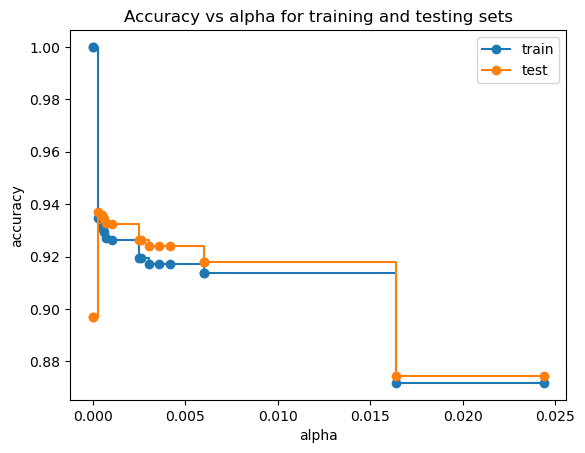

In [198]:
#plotting to determine the best alpha
fig, ax = plt.subplots()

ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")

ax.plot(ccp_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores,  marker='o', label="test",  drawstyle="steps-post")

ax.legend()
plt.show()

In [199]:
# calculation of best alpha
cv_scores = []

for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(dt, X_train, y_train, cv=5)  # 5-fold CV
    cv_scores.append(scores.mean())

best_alpha = ccp_alphas[np.argmax(cv_scores)]
print(f"Best alpha via Cross Validation: {best_alpha}")

Best alpha via Cross Validation: 0.00027411183965400134


# TRAINING AND INTERPRETING THE BEST DECISION TREE

In [200]:
best_model = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

best_model.fit(X_train, y_train)
print(f"Train Accuracy: {best_model.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {best_model.score(X_test, y_test):.4f}")

Train Accuracy: 0.9346
Test Accuracy:  0.9370


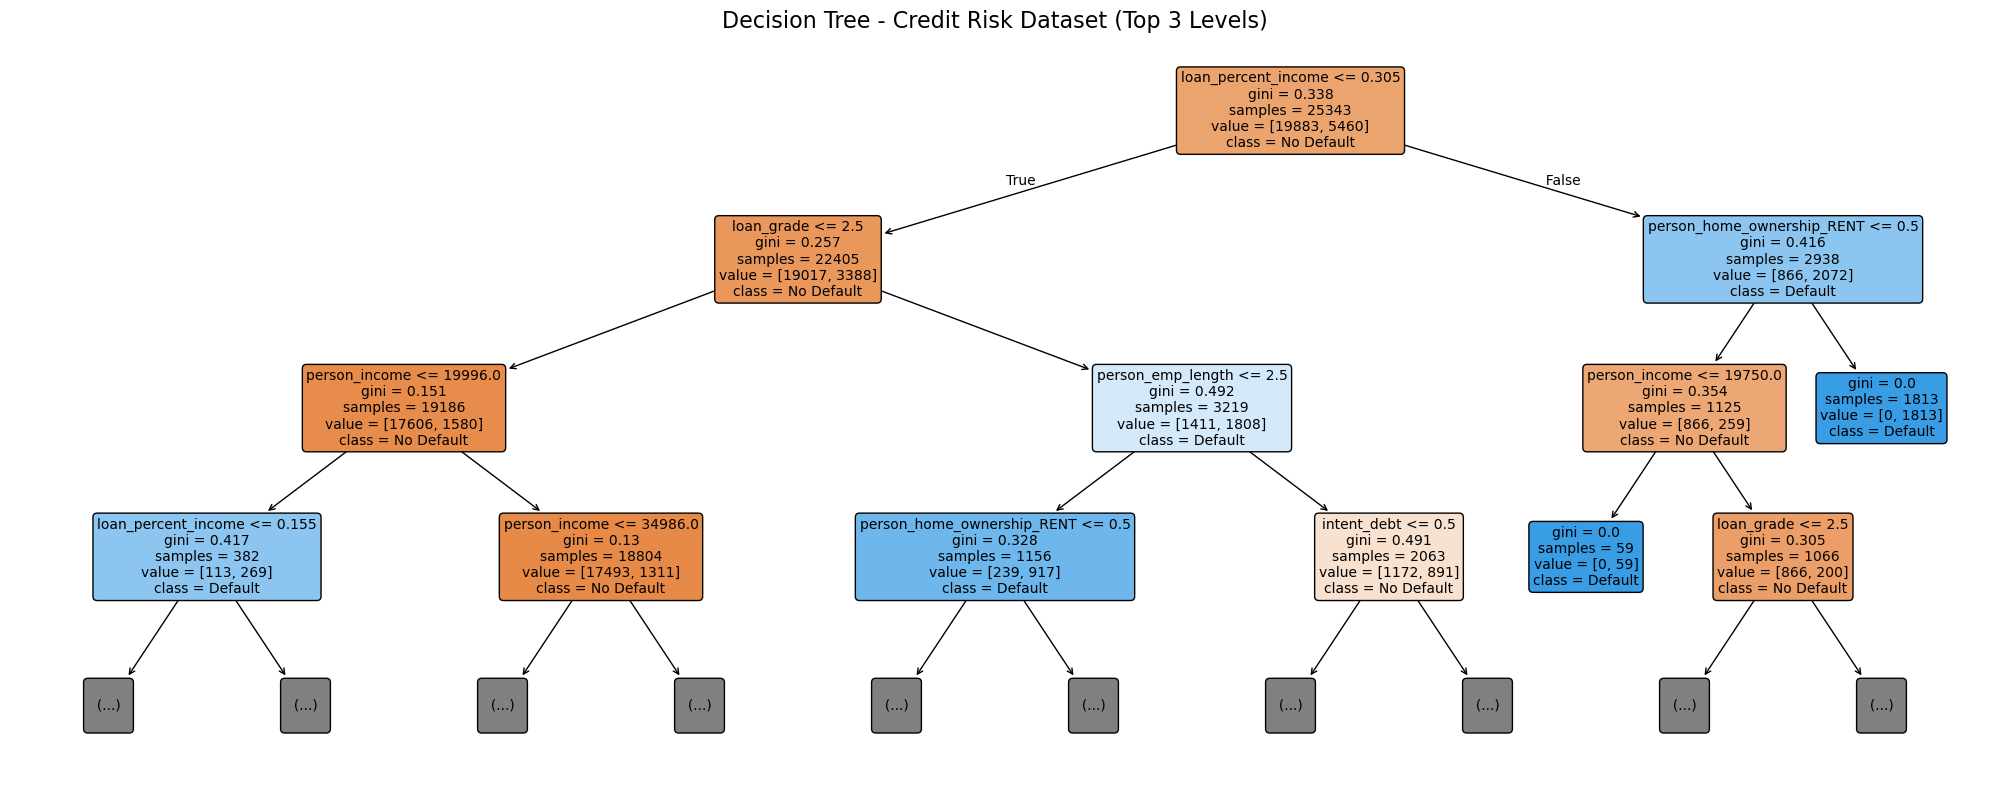

In [201]:
plt.figure(figsize=(20, 8))

plot_tree(
    best_model,
    feature_names=X.columns.tolist(),
    class_names=['No Default', 'Default'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3        # Only show first 3 levels
)

plt.title("Decision Tree - Credit Risk Dataset (Top 3 Levels)", fontsize=16)
plt.tight_layout()
plt.show()

In [202]:
# EVALUATING OUR BEST MODEL
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

In [203]:
# Evaluation
print("\n MODEL EVALUATION ")
print(classification_report(y_test, y_pred_best, target_names=['Repaid (0)', 'Defaulted (1)']))

roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)
print(f"ROC-AUC Score: {roc_auc_best:.4f}")


 MODEL EVALUATION 
               precision    recall  f1-score   support

   Repaid (0)       0.93      1.00      0.96      4971
Defaulted (1)       0.99      0.72      0.83      1365

     accuracy                           0.94      6336
    macro avg       0.96      0.86      0.90      6336
 weighted avg       0.94      0.94      0.93      6336

ROC-AUC Score: 0.9179


## Model Evaluation - Pruned vs Unpruned

### Pruned Model

- **Accuracy: 94%** vs unpruned 92% shows that pruning improved overall accuracy
- **ROC-AUC: 0.9179** vs unpruned 0.9006 and this is better at separating defaulters and repayers
- **Precision on Defaulted (1): 0.99** means when it predicts default, it is correct 99% of the time
- **Recall on Defaulted (1): 0.72** it catches 72% of actual defaulters, misses 28%

### The One Trade-off

Recall is 0.72 in both models and pruning did not improve this

So around 1 in 4 actual defaulters are still being predicted as repayers

This is something that can be improved later by focusing more on recall

### Overall

Pruned model has higher accuracy, higher AUC and much higher precision on defaults

So pruning made the tree simpler while still keeping good performance

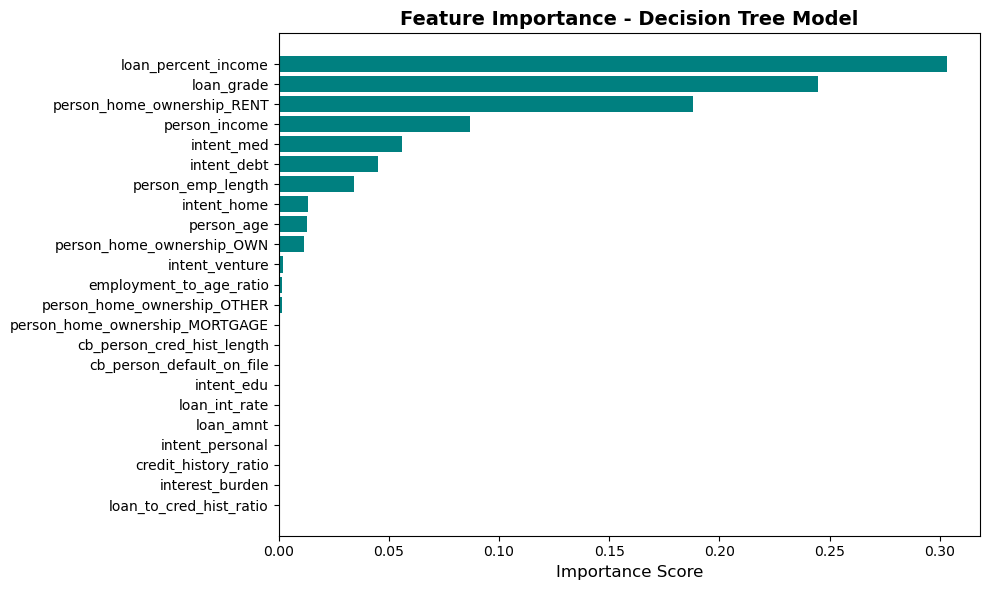

In [204]:
# Feature Importance (The "Explainability" Factor)
importances = best_model.feature_importances_
feature_names = X.columns

# Create a dataframe to sort and view the top drivers of default
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# 3. Plot the Feature Importance
plt.figure(figsize=(10, 6))

# Horizontal bar chart
plt.barh(importance_df['feature'], importance_df['importance'], color='teal')

# Formatting
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance - Decision Tree Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Puts the highest importance feature at the very top
plt.tight_layout()        # Prevents labels from being cut off

# Save the image for your GitHub/Portfolio
plt.savefig('feature_importance_dt.png', dpi=300, bbox_inches='tight')

plt.show()


## Feature Importance Analysis (Post-Pruning)

After pruning, the tree became simpler and now depends more on a few important features

### 1. Main Features

The top 3 features make up more than **70%** of the total importance

- **`loan_percent_income` (~30%)**
  - Now the most important feature
  - Shows how much of the income goes towards the loan
  - Higher percentage means more financial pressure

- **`loan_grade` (~24%)**
  - Still one of the main features
  - Lower grades like D, E and F are linked with higher default risk
  - The pruned tree uses this as one of the main splits

- **`person_home_ownership_RENT` (~19%)**
  - Importance increased compared to the previous tree
  - Renters show higher default risk in this dataset
  - The simpler tree is using this feature as a broader split

### 2. Secondary Predictors

- **`person_income` (~9%)**
  - Gives an idea about repayment capacity
  - Higher income can give more room to handle the loan

- **`intent_med` and `intent_debt`**
  - These also have some importance
  - Medical and debt consolidation loans may be linked with more financial pressure

### 3. Why Some Features Have Zero Importance

Features like `loan_int_rate`, `loan_amnt` and the engineered ratios have very low importance

- The pruned tree is using a few strong features for its main splits
- Once these features separate the data, other features may not add much
- Pruning also removes less useful branches
- So the engineered ratios are not contributing much in this tree

<Figure size 800x600 with 0 Axes>

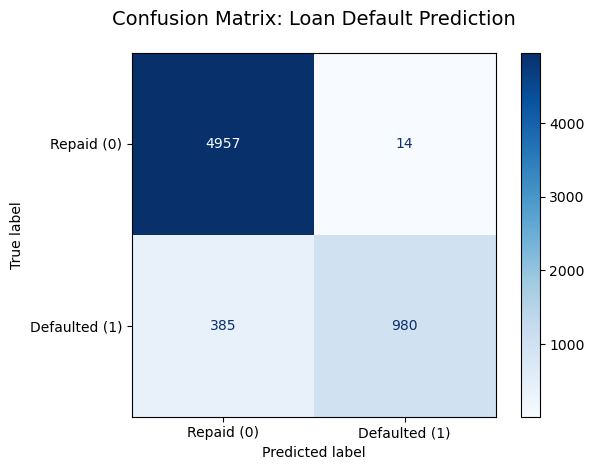

In [205]:
plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_estimator(
    best_model,                # Your trained Decision Tree
    X_test, 
    y_test,
    display_labels=["Repaid (0)", "Defaulted (1)"],
    cmap="Blues",         
    values_format="d"     # Display whole numbers instead of decimals
)

plt.title("Confusion Matrix: Loan Default Prediction", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Evaluating the Pruned Classification Tree

After pruning, the confusion matrix shows some changes in model performance

### Key Metrics:

* **Out of 4,971 people who repaid the loan** (4957 + 14), **4,957 (99.7%)** were correctly classified
  - Almost all repayers are being classified correctly

* **Out of 1,365 people who defaulted** (385 + 980), **980 (71.8%)** were correctly identified
  - Model catches around 3 out of 4 defaulters

* **The model missed 385 defaulters**
  - These are the False Negatives
  - These defaulters were predicted as repayers

* **When the model predicts default, it is correct 98.6% of the time** (980 / 994)
  - Very high precision
  - Only 14 repayers were incorrectly flagged as defaulters

### Before Pruning → After Pruning

- False Positives reduced to just **14**
- Precision increased from **89% to 98.6%**
- Recall is still around **72%**
- So the model is very good at avoiding false default flags, but still misses some actual defaulters

### Can we do better?

One possible way to catch more defaulters would be to adjust the classification threshold or try models like Random Forest

For now, the pruned tree gives a simple and interpretable baseline with good precision and around 72% recall for defaulters

# Conclusion

Built a Decision Tree model to predict loan defaults on a dataset of ~31,000 borrowers

After preprocessing, feature engineering and pruning, the final model gives:

- **Test Accuracy: 93.7%**
- **ROC-AUC: 0.9179**
- **Precision on defaults: 99%** — almost always correct when it flags a defaulter
- **Recall on defaults: 72%** — catches around 3 out of 4 actual defaulters

Main limitation is recall — 28% of actual defaulters are still missed

Next step could be trying Random Forest or adjusting the classification threshold to improve recall